In [4]:
import pandas as pd
df = pd.read_csv("/home/alejo/Projects/University/Fundamentos-de-la-Ciencia-de-Datos/Archivos/obesity_1.csv")
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
#Estudiar numero de hombres y mujeres en la muestra.
conteo_genero = df['Gender'].value_counts()
print(conteo_genero)

Gender
Male      1068
Female    1043
Name: count, dtype: int64


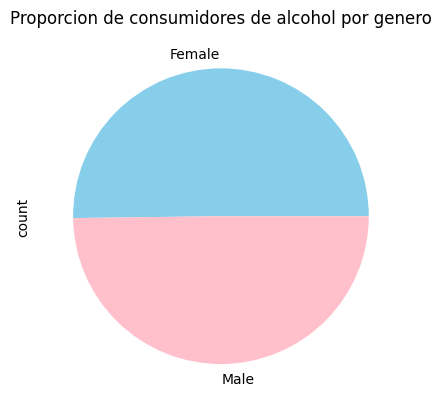

In [17]:
#Proporción de consumidores de alcohol mujeres y hombres.
import matplotlib.pyplot as plt
consumidores = df[df['CALC']!='no']
conteo_genero = consumidores['Gender'].value_counts()
conteo_genero.plot(kind='pie', colors=['skyblue', 'pink'])
plt.title('Proporcion de consumidores de alcohol por genero')
plt.show()

<bound method DataFrame.corr of             Age      Weight
0     21.000000   64.000000
1     21.000000   56.000000
2     23.000000   77.000000
3     27.000000   87.000000
4     22.000000   89.800000
...         ...         ...
2106  20.976842  131.408528
2107  21.982942  133.742943
2108  22.524036  133.689352
2109  24.361936  133.346641
2110  23.664709  133.472641

[2111 rows x 2 columns]>


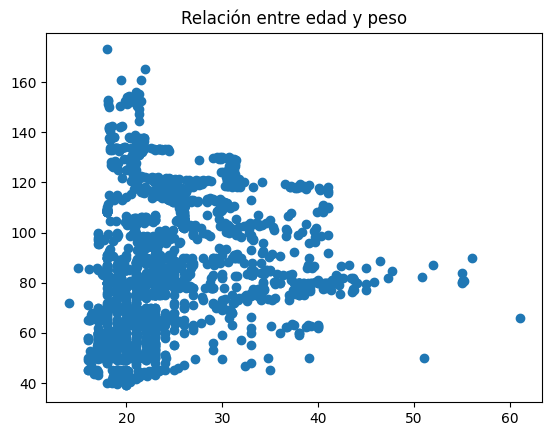

In [29]:
#Relación de edad y peso.
import matplotlib.pyplot as plt
print(df[['Age', 'Weight']].corr)
plt.scatter(df['Age'], df['Weight'])
plt.title("Relación entre edad y peso")
plt.show()

<bound method DataFrame.corr of         Height      Weight
0     1.620000   64.000000
1     1.520000   56.000000
2     1.800000   77.000000
3     1.800000   87.000000
4     1.780000   89.800000
...        ...         ...
2106  1.710730  131.408528
2107  1.748584  133.742943
2108  1.752206  133.689352
2109  1.739450  133.346641
2110  1.738836  133.472641

[2111 rows x 2 columns]>


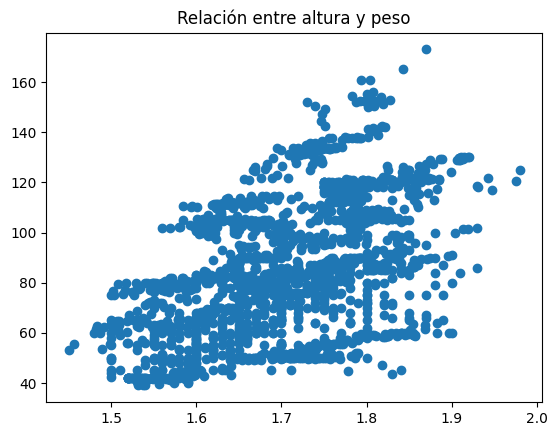

In [30]:
#Relación de altura y peso.
import matplotlib.pyplot as plt
print(df[['Height', 'Weight']].corr)
plt.scatter(df['Height'], df['Weight'])
plt.title("Relación entre altura y peso")
plt.show()

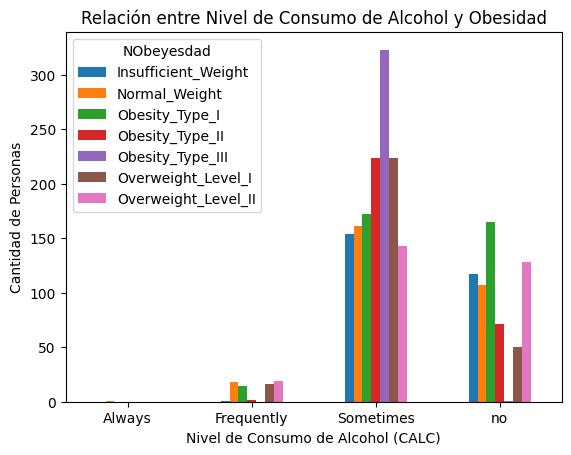

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Creamos la tabla de contingencia cruzando ambas variables categóricas
# Esto cuenta cuántas personas hay en cada combinación de "consumo de alcohol" y "nivel de obesidad"
tabla_cruzada = pd.crosstab(df['CALC'], df['NObeyesdad'])

# 2. Generamos el gráfico de barras apiladas usando el método .plot() de Pandas
# 'stacked=True' hace que las categorías de obesidad se apilen sobre cada barra de alcohol
tabla_cruzada.plot(kind='bar')

# 3. Agregamos etiquetas, título y leyenda para que sea legible
plt.title('Relación entre Nivel de Consumo de Alcohol y Obesidad')
plt.xlabel('Nivel de Consumo de Alcohol (CALC)')
plt.ylabel('Cantidad de Personas')

# Rotamos las etiquetas del eje X para que no se encimen
plt.xticks(rotation=0)

plt.show()

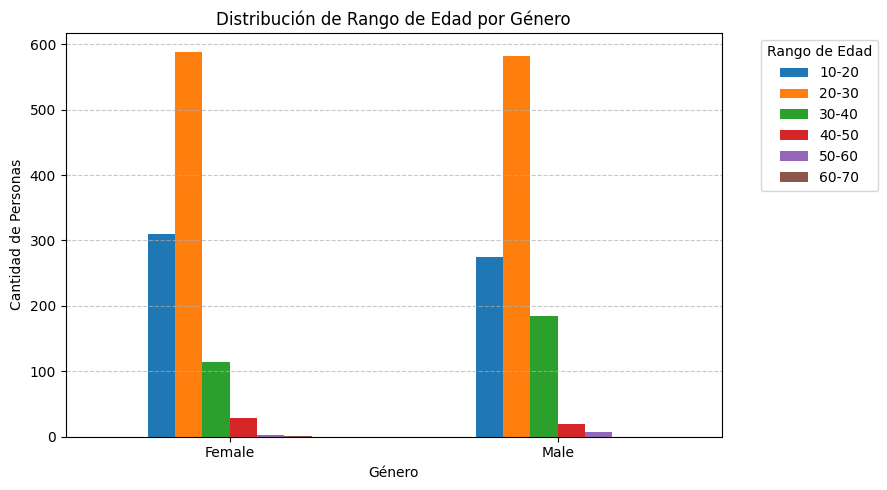

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Creamos los rangos de edad en el DataFrame
df['Rango_Edad'] = pd.cut(df['Age'], bins=[10, 20, 30, 40, 50, 60, 70], labels=['10-20', '20-30', '30-40', '40-50', '50-60', '60-70'])

# 2. Armamos la tabla cruzada entre Género y los nuevos rangos
tabla_edades = pd.crosstab(df['Gender'], df['Rango_Edad'])

# 3. Graficamos la tabla cruzada (¡no el df!)
tabla_edades.plot(kind='bar', figsize=(9, 5))

plt.title('Distribución de Rango de Edad por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=0)
plt.legend(title='Rango de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

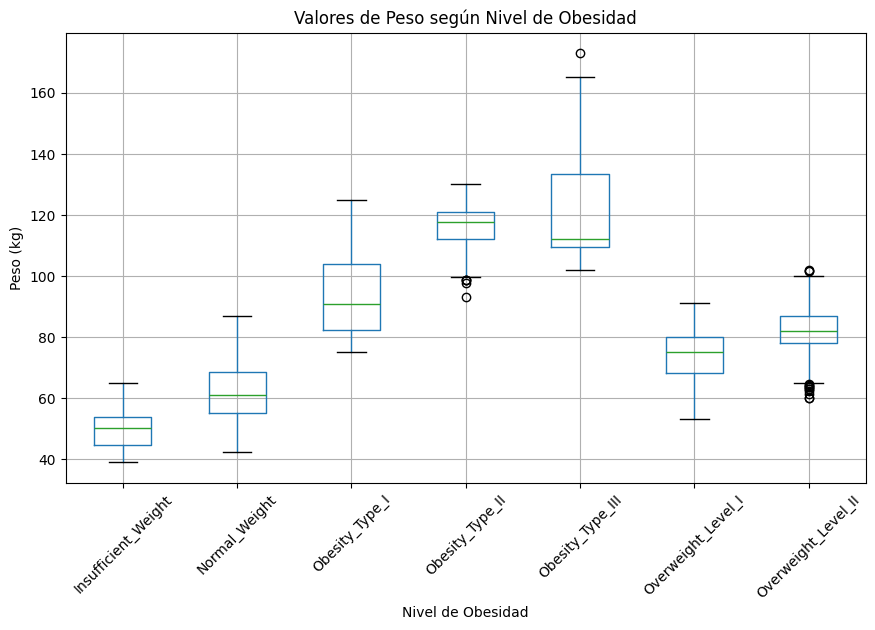

In [53]:
#Valores de peso segun grado de obesidad.
import matplotlib.pyplot as plt

# Genera un boxplot que muestra el peso (column) agrupado por cada nivel de obesidad (by)
df.boxplot(column='Weight', by='NObeyesdad', figsize=(10, 6))

plt.title('Valores de Peso según Nivel de Obesidad')
plt.xlabel('Nivel de Obesidad')
plt.ylabel('Peso (kg)')
plt.suptitle('')  # Esto saca un título automático feo que pone pandas arriba
plt.xticks(rotation=45)
plt.show()

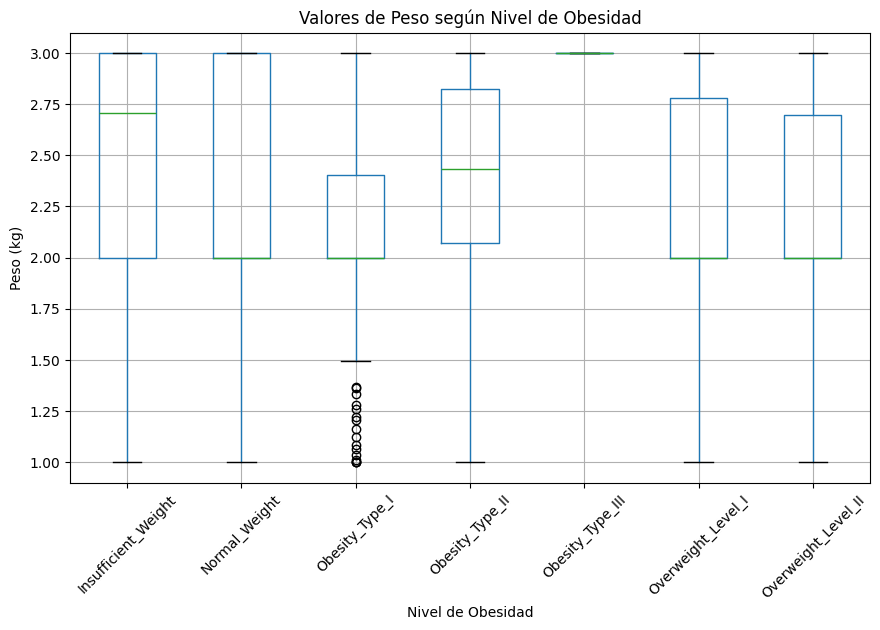

In [54]:
#Consumo de vegetales con obesidad.
import matplotlib.pyplot as plt

# Genera un boxplot que muestra el peso (column) agrupado por cada nivel de obesidad (by)
df.boxplot(column='FCVC', by='NObeyesdad', figsize=(10, 6))

plt.title('Valores de Peso según Nivel de Obesidad')
plt.xlabel('Nivel de Obesidad')
plt.ylabel('Peso (kg)')
plt.suptitle('')  # Esto saca un título automático feo que pone pandas arriba
plt.xticks(rotation=45)
plt.show()